# Real-data blind ptychography on NVIDIA CUDA: Chip, complete scan

Complete measured chip scan (812 diffraction patterns at 512 x 512 pixels). This notebook targets the RTX PRO 6000 Blackwell
CUDA environment. It compares rPIE, Gaussian LSQML (sigma=0.5, beta=0.5), GM-rPIE, and
GM-MAGPIE with identical selected frames and seeded random minibatches.
Real-data diagnostics use only the online residual. Raw complex object
and probe snapshots are saved and displayed every 100 epochs.


In [1]:
# ruff: noqa: E402 -- configure the project path before local imports.
import gc
import os
from copy import deepcopy
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import sys
import tempfile
from time import perf_counter

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "magpie-matplotlib"),
)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src" / "utils" / "real_result_archive.py").is_file()
    and (candidate / "assets" / "ptycho_real_data").is_dir()
)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import ptychi.api as api
import torch
from IPython.display import display

from algorithms.lsqml import LSQMLHyperparameters
from utils.common import configure_ptychi_device, cuda_runtime_preflight
from utils.phase_alignment import align_blind_object_probe
from utils.real_data import (
    RealDataConfig,
    load_real_dataset,
    run_real_gm_magpie,
    run_real_gm_rpie,
    run_real_lsqml,
    run_real_rpie,
)
from utils.real_result_archive import (
    RealResultArchiveSession,
    save_real_reconstruction_snapshot,
    save_real_notebook_results,
    validate_real_method_checkpoint,
)


In [2]:
BASE_EXPERIMENT_NAME = 'chip_full'

# Set this to True for a one-epoch, one-minibatch CUDA/NVRTC smoke run.
# False is the configured production experiment. Smoke archives use a
# separate *_smoke directory and cannot be confused with production.
SMOKE_TEST = False

PRODUCTION_NUM_EPOCHS = 200
PRODUCTION_REPORT_EVERY = 100
PRODUCTION_SNAPSHOT_EVERY = 100
# All four methods share this notebook's batch size and epoch count.
BATCH_SIZE = 29
NUM_EPOCHS = 1 if SMOKE_TEST else PRODUCTION_NUM_EPOCHS
MAX_PATTERNS = BATCH_SIZE if SMOKE_TEST else None
REPORT_EVERY = 1 if SMOKE_TEST else PRODUCTION_REPORT_EVERY
SNAPSHOT_EVERY = 1 if SMOKE_TEST else PRODUCTION_SNAPSHOT_EVERY

EXPERIMENT_NAME = (
    f"{BASE_EXPERIMENT_NAME}_smoke" if SMOKE_TEST
    else BASE_EXPERIMENT_NAME
)
NOTEBOOK_PATH = (
    PROJECT_ROOT / "examples" / "real_data"
    / f"{BASE_EXPERIMENT_NAME}.ipynb"
)
RESULTS_ROOT = (
    PROJECT_ROOT / "results" / "notebook_exports" / EXPERIMENT_NAME
)
RUN_STARTED_UTC = datetime.now(timezone.utc)
RUN_ID = RUN_STARTED_UTC.strftime("%Y%m%dT%H%M%S_%fZ")
RUN_SEQUENCE = 1

DATA_PATH = (
    PROJECT_ROOT / "assets" / "ptycho_real_data"
    / 'Velo_18c3_comm_chip65nm_scan054_data_roi0_Ndp512_us2.hdf5'
)
PRODUCTION_PATTERN_COUNT = 812
SOURCE_PATTERN_COUNT = 812
DETECTOR_SIZE = 512
EXPECTED_PATTERN_COUNT = (
    BATCH_SIZE if SMOKE_TEST else PRODUCTION_PATTERN_COUNT
)
RANDOM_PATTERN_FRACTION = None
RECONSTRUCTION_SEED = 42
OBJECT_EXTRA_PIXELS = 20
SAVE_DATA_ON_DEVICE = True
ALIGNMENT_SCALE_AMPLITUDE = True

SAMPLED_METRIC_KEYS = ()
FINAL_METRIC_KEYS = ()

# Alpha pairs are object / probe. rPIE uses the GM-rPIE settings below.
GM_RPIE_OBJECT_ALPHA = 1.0
GM_RPIE_PROBE_ALPHA = 0.1
GM_MAGPIE_OBJECT_ALPHA = 3.0
GM_MAGPIE_PROBE_ALPHA = 0.1

shared_cfg = RealDataConfig(
    data_path=DATA_PATH,
    fzp_defocus_m=-1e-3,
    pattern_stride=1,
    max_patterns=MAX_PATTERNS,
    fft_shift_data=True,
    random_pattern_fraction=RANDOM_PATTERN_FRACTION,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    object_extra_pixels=OBJECT_EXTRA_PIXELS,
    seed=RECONSTRUCTION_SEED,
    object_step_size=1.0,
    probe_step_size=1.0,
    save_data_on_device=SAVE_DATA_ON_DEVICE,
    remove_object_probe_ambiguity=True,
)
gm_rpie_cfg = replace(
    shared_cfg,
    object_alpha=GM_RPIE_OBJECT_ALPHA,
    probe_alpha=GM_RPIE_PROBE_ALPHA,
)
rpie_cfg = replace(gm_rpie_cfg)
gm_magpie_cfg = replace(
    shared_cfg,
    object_alpha=GM_MAGPIE_OBJECT_ALPHA,
    probe_alpha=GM_MAGPIE_PROBE_ALPHA,
)
# LSQML has two layers of step-size control. The outer SGD steps remain
# 1.0. All measured-data notebooks use the selected Gaussian likelihood
# with sigma=0.5 and tied solved optimal-step scalers beta=0.5.
LSQML_NOISE_MODEL = api.NoiseModels.GAUSSIAN
LSQML_GAUSSIAN_NOISE_STD = 0.5
LSQML_STEP_SIZE_SCALER = 0.5
lsqml_cfg = replace(
    shared_cfg,
    object_step_size=1.0,
    probe_step_size=1.0,
)
lsqml_noise_kwargs = {}
if LSQML_NOISE_MODEL == api.NoiseModels.GAUSSIAN:
    lsqml_noise_kwargs["gaussian_noise_std"] = (
        LSQML_GAUSSIAN_NOISE_STD
    )
lsqml_hyperparameters = LSQMLHyperparameters(
    object_step_size_scaler=LSQML_STEP_SIZE_SCALER,
    probe_step_size_scaler=LSQML_STEP_SIZE_SCALER,
    noise_model=LSQML_NOISE_MODEL,
    **lsqml_noise_kwargs,
)
LSQML_PARAMETERS = {
    "noise_model": 'gaussian',
    "object_step_size": 1.0,
    "probe_step_size": 1.0,
    "object_optimal_step_size_scaler": LSQML_STEP_SIZE_SCALER,
    "probe_optimal_step_size_scaler": LSQML_STEP_SIZE_SCALER,
}
LSQML_PARAMETERS.update(lsqml_noise_kwargs)

METHOD_ORDER = ("rPIE", "LSQML", "GM-rPIE", "GM-MAGPIE")
METHOD_FILE_STEMS = {
    "rPIE": "rpie",
    "LSQML": "lsqml",
    "GM-rPIE": "gm_rpie",
    "GM-MAGPIE": "gm_magpie",
}
METHOD_COLORS = {
    "rPIE": "#55A868",
    "LSQML": "#4C72B0",
    "GM-rPIE": "#C44E52",
    "GM-MAGPIE": "#DD8452",
}
METHOD_CONFIGS = {
    "rPIE": rpie_cfg,
    "LSQML": lsqml_cfg,
    "GM-rPIE": gm_rpie_cfg,
    "GM-MAGPIE": gm_magpie_cfg,
}
METHOD_PARAMETERS = {
    "rPIE": {"runner": "run_real_rpie", "config": rpie_cfg},
    "LSQML": {
        "runner": "run_real_lsqml",
        "config": lsqml_cfg,
        "hyperparameters": LSQML_PARAMETERS,
    },
    "GM-rPIE": {
        "runner": "run_real_gm_rpie",
        "config": gm_rpie_cfg,
        "effective_multigrid_levels": 1,
    },
    "GM-MAGPIE": {
        "runner": "run_real_gm_magpie",
        "config": gm_magpie_cfg,
        "requested_multigrid_levels": None,
        "effective_multigrid_levels": 10,
    },
}
METRIC_DEFINITIONS = {
    "online_preupdate_residual": (
        "Pty-Chi online minibatch amplitude loss, aggregated once per "
        "epoch before each minibatch update."
    ),
}

if NUM_EPOCHS < 1 or REPORT_EVERY < 1 or SNAPSHOT_EVERY < 1:
    raise ValueError(
        "NUM_EPOCHS, REPORT_EVERY, and SNAPSHOT_EVERY must be positive."
    )
if SMOKE_TEST:
    print(
        "SMOKE TEST: one epoch and one minibatch; results are not the "
        "production experiment."
    )

results = {}
runtimes_seconds = {}


## Helpers


In [3]:
def lsqml_parameter_record(config, hyperparameters):
    noise_model = getattr(
        hyperparameters.noise_model,
        "value",
        str(hyperparameters.noise_model),
    )
    noise_model = str(noise_model).rsplit(".", maxsplit=1)[-1].lower()
    if noise_model not in {"poisson", "gaussian"}:
        raise ValueError(f"Unsupported LSQML noise model: {noise_model}")
    parameters = {
        "noise_model": noise_model,
        "object_step_size": float(config.object_step_size),
        "probe_step_size": float(config.probe_step_size),
        "object_optimal_step_size_scaler": float(
            hyperparameters.object_step_size_scaler
        ),
        "probe_optimal_step_size_scaler": float(
            hyperparameters.probe_step_size_scaler
        ),
    }
    if noise_model == "gaussian":
        noise_std = hyperparameters.gaussian_noise_std
        if noise_std is None or not np.isfinite(noise_std) or noise_std <= 0:
            raise ValueError(
                "Gaussian LSQML requires a positive finite noise standard "
                "deviation."
            )
        parameters["gaussian_noise_std"] = float(noise_std)
    return parameters


def refresh_method_definitions(
    method_name=None,
    config=None,
    *,
    hyperparameters=None,
):
    # Capture the exact live objects that the next method call uses.
    global METHOD_CONFIGS, METHOD_PARAMETERS, LSQML_PARAMETERS

    if method_name is not None and method_name not in METHOD_ORDER:
        raise ValueError(f"Unknown method {method_name!r}.")
    configs = {
        "rPIE": rpie_cfg,
        "LSQML": lsqml_cfg,
        "GM-rPIE": gm_rpie_cfg,
        "GM-MAGPIE": gm_magpie_cfg,
    }
    if method_name is not None:
        if config is None:
            raise ValueError("The actual method config is required.")
        configs[method_name] = config

    active_lsqml_hyperparameters = (
        hyperparameters
        if method_name == "LSQML"
        else lsqml_hyperparameters
    )
    if active_lsqml_hyperparameters is None:
        raise ValueError("LSQML hyperparameters are required.")
    LSQML_PARAMETERS = lsqml_parameter_record(
        configs["LSQML"],
        active_lsqml_hyperparameters,
    )
    METHOD_CONFIGS = configs
    METHOD_PARAMETERS = {
        "rPIE": {
            "runner": "run_real_rpie",
            "config": configs["rPIE"],
        },
        "LSQML": {
            "runner": "run_real_lsqml",
            "config": configs["LSQML"],
            "hyperparameters": LSQML_PARAMETERS,
        },
        "GM-rPIE": {
            "runner": "run_real_gm_rpie",
            "config": configs["GM-rPIE"],
            "effective_multigrid_levels": 1,
        },
        "GM-MAGPIE": {
            "runner": "run_real_gm_magpie",
            "config": configs["GM-MAGPIE"],
            "requested_multigrid_levels": None,
            "effective_multigrid_levels": valid_dyadic_levels(
                *dataset.probe_init.shape[-2:]
            )[0],
        },
    }
    return deepcopy(METHOD_PARAMETERS)


def _method_artifact_paths(method_name, run_id):
    stem = METHOD_FILE_STEMS[method_name]
    checkpoint_root = RESULTS_ROOT / "_checkpoints" / run_id
    candidates = (
        checkpoint_root / stem,
        checkpoint_root / "_epoch_snapshots" / stem,
        RESULTS_ROOT / run_id,
    )
    return tuple(path for path in candidates if path.exists())


def start_new_trial(reason="manual parameter-tuning trial"):
    # Start a fresh immutable run namespace without reloading the data.
    global RUN_STARTED_UTC, RUN_ID, RUN_SEQUENCE, STATE_RUN_ID
    global alignment_fit_mask, archive_session, RUN_METADATA

    previous_run_id = RUN_ID
    while True:
        run_started_utc = datetime.now(timezone.utc)
        run_id = run_started_utc.strftime("%Y%m%dT%H%M%S_%fZ")
        if not (
            (RESULTS_ROOT / "_checkpoints" / run_id).exists()
            or (RESULTS_ROOT / run_id).exists()
        ):
            break

    RUN_STARTED_UTC = run_started_utc
    RUN_ID = run_id
    RUN_SEQUENCE += 1
    STATE_RUN_ID = RUN_ID
    results.clear()
    runtimes_seconds.clear()
    aligned_objects.clear()
    aligned_probes.clear()
    alignments.clear()
    alignment_fit_mask = None
    archive_session = None
    globals().pop("saved_run_dir", None)
    if isinstance(globals().get("RUN_METADATA"), dict):
        RUN_METADATA = {
            **RUN_METADATA,
            "run_sequence": RUN_SEQUENCE,
            "trial_parent_run_id": previous_run_id,
            "trial_start_reason": str(reason),
        }
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(
        f"Started fresh trial run {RUN_ID}. "
        f"Previous run {previous_run_id} remains unchanged."
    )
    print(f"Reason: {reason}")
    return RUN_ID


def begin_method_run(
    method_name,
    config,
    *,
    hyperparameters=None,
):
    # Roll over before any conflicting GPU work starts.
    refresh_method_definitions(
        method_name,
        config,
        hyperparameters=hyperparameters,
    )
    reasons = []
    if globals().get("STATE_RUN_ID") != RUN_ID:
        reasons.append("the settings cell created a different run ID")
    if archive_session is not None:
        if archive_session.run_id != RUN_ID:
            reasons.append("the active archive belongs to another run ID")
        if METHOD_PARAMETERS != archive_session.method_parameters:
            reasons.append("a method configuration changed")
    if method_name in results:
        reasons.append(f"{method_name} already completed in this run")
    artifacts = _method_artifact_paths(method_name, RUN_ID)
    if artifacts:
        reasons.append(
            f"{method_name} already has saved artifacts in this run"
        )

    if reasons:
        start_new_trial("; ".join(dict.fromkeys(reasons)))
        refresh_method_definitions(
            method_name,
            config,
            hyperparameters=hyperparameters,
        )

    remaining = _method_artifact_paths(method_name, RUN_ID)
    if remaining:
        raise FileExistsError(
            "Fresh trial target unexpectedly exists: "
            + ", ".join(str(path) for path in remaining)
        )
    print(f"{method_name} trial run ID: {RUN_ID}")
    return RUN_ID


def saved_trials(method_name=None):
    # Return verified method-checkpoint manifests from prior trials.
    if method_name is not None and method_name not in METHOD_ORDER:
        raise ValueError(f"Unknown method {method_name!r}.")
    checkpoint_root = RESULTS_ROOT / "_checkpoints"
    records = []
    if not checkpoint_root.is_dir():
        return records
    methods = METHOD_ORDER if method_name is None else (method_name,)
    for run_directory in sorted(checkpoint_root.iterdir()):
        if not run_directory.is_dir():
            continue
        for name in methods:
            method_directory = run_directory / METHOD_FILE_STEMS[name]
            manifest_path = method_directory / "method_manifest.json"
            success_path = method_directory / "_SUCCESS"
            if not (manifest_path.is_file() and success_path.is_file()):
                continue
            manifest = validate_real_method_checkpoint(method_directory)
            records.append(
                {
                    "run_id": run_directory.name,
                    "method": name,
                    "checkpoint": method_directory,
                    "parameters": manifest["parameters"],
                    "runtime_seconds": float(manifest["runtime_seconds"]),
                    "final_online_preupdate_residual": float(
                        manifest["final_online_preupdate_residual"]
                    ),
                }
            )
    return records


def show_saved_trials(method_name=None):
    # Print a compact table; do not call any measured-data trial "best".
    records = saved_trials(method_name)
    if not records:
        print("No completed trials found.")
        return records
    print(
        f"{'run ID':<25} {'method':<11} {'obj alpha':>10} "
        f"{'probe alpha':>12} {'minutes':>10} {'final online':>14}"
    )
    print("-" * 88)
    for record in records:
        config = record["parameters"].get("config", {})
        object_alpha = config.get("object_alpha", "-")
        probe_alpha = config.get("probe_alpha", "-")
        print(
            f"{record['run_id']:<25} {record['method']:<11} "
            f"{str(object_alpha):>10} {str(probe_alpha):>12} "
            f"{record['runtime_seconds'] / 60:>10.2f} "
            f"{record['final_online_preupdate_residual']:>14.6e}"
        )
    return records


def robust_limits(values, percentiles, *, nonnegative=False):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return 0.0, 1.0
    low, high = (float(value) for value in np.percentile(finite, percentiles))
    if nonnegative:
        low = max(0.0, low)
    if high <= low:
        high = low + max(1e-6, 1e-3 * max(abs(low), 1.0))
    return low, high


def outer_border_mask(shape, boundary_width):
    height, width = shape
    cutoff_y, cutoff_x = boundary_width
    if 2 * cutoff_y >= height or 2 * cutoff_x >= width:
        raise ValueError("Half-probe boundary leaves no object interior.")
    mask = np.ones(shape, dtype=bool)
    mask[
        cutoff_y : height - cutoff_y,
        cutoff_x : width - cutoff_x,
    ] = False
    return mask


def valid_dyadic_levels(height, width):
    levels = 1
    while height % 2 == 0 and width % 2 == 0 and min(height, width) >= 2:
        height //= 2
        width //= 2
        levels += 1
    return levels, (height, width)


def make_progress_callback(method_name):
    def report(epoch, online_residual, metrics):
        if metrics:
            raise ValueError("Real-data runs should report online residual only.")
        print(
            f"\r{method_name}: epoch {epoch}/{NUM_EPOCHS}, "
            f"online={online_residual:.3e}",
            end="",
            flush=True,
        )

    return report


def make_snapshot_callback(method_name, run_id):
    method_file_stem = METHOD_FILE_STEMS[method_name]

    def save_and_display(epoch, object_snapshot, probe_snapshot):
        snapshot_path = save_real_reconstruction_snapshot(
            RESULTS_ROOT,
            run_id=run_id,
            method=method_name,
            method_file_stem=method_file_stem,
            epoch=epoch,
            object_snapshot=object_snapshot,
            probe_snapshot=probe_snapshot,
        )

        object_raw = np.squeeze(object_snapshot)
        probe_raw = np.squeeze(probe_snapshot)
        boundary = tuple(length // 2 for length in probe_raw.shape[-2:])
        object_view = tuple(
            slice(cutoff, length - cutoff)
            for cutoff, length in zip(boundary, object_raw.shape)
        )
        object_display = object_raw[object_view]
        object_magnitude = np.abs(object_display)
        probe_magnitude = np.abs(probe_raw)
        object_limits = robust_limits(
            object_magnitude,
            (2, 98),
            nonnegative=True,
        )
        probe_vmax = robust_limits(
            probe_magnitude,
            (0, 99.5),
            nonnegative=True,
        )[1]
        probe_phase = np.ma.masked_where(
            probe_magnitude < 0.05 * probe_vmax,
            np.angle(probe_raw),
        )

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(9.5, 8.0),
            constrained_layout=True,
        )
        object_magnitude_image = axes[0, 0].imshow(
            object_magnitude,
            cmap="gray",
            vmin=object_limits[0],
            vmax=object_limits[1],
        )
        object_phase_image = axes[1, 0].imshow(
            np.angle(object_display),
            cmap="gray",
            vmin=-np.pi,
            vmax=np.pi,
        )
        probe_magnitude_image = axes[0, 1].imshow(
            probe_magnitude,
            cmap="gray",
            vmin=0,
            vmax=probe_vmax,
        )
        probe_phase_image = axes[1, 1].imshow(
            probe_phase,
            cmap="gray",
            vmin=-np.pi,
            vmax=np.pi,
        )
        axes[0, 0].set_title("Object magnitude")
        axes[1, 0].set_title("Object phase")
        axes[0, 1].set_title("Probe magnitude")
        axes[1, 1].set_title("Probe phase (low magnitude masked)")
        for axis in axes.flat:
            axis.set(xticks=[], yticks=[])
        fig.colorbar(object_magnitude_image, ax=axes[0, 0], shrink=0.82)
        fig.colorbar(
            object_phase_image,
            ax=axes[1, 0],
            shrink=0.82,
            label="rad",
        )
        fig.colorbar(probe_magnitude_image, ax=axes[0, 1], shrink=0.82)
        fig.colorbar(
            probe_phase_image,
            ax=axes[1, 1],
            shrink=0.82,
            label="rad",
        )
        fig.suptitle(f"{method_name} reconstruction after epoch {epoch}")
        display(fig)
        plt.close(fig)
        print(f"\nSaved epoch-{epoch} reconstruction: {snapshot_path}")

    return save_and_display


def reconstruction_kwargs(method_name, run_id):
    return {
        "seed": RECONSTRUCTION_SEED,
        "report_stride": REPORT_EVERY,
        "progress_callback": make_progress_callback(method_name),
        "snapshot_callback": make_snapshot_callback(method_name, run_id),
        "snapshot_stride": SNAPSHOT_EVERY,
        "chunk_epochs": True,
    }


def validate_result(method_name, result):
    if result.residual_history.shape != (NUM_EPOCHS,):
        raise ValueError(f"{method_name}: unexpected residual shape.")
    if not np.all(np.isfinite(result.residual_history)):
        raise ValueError(f"{method_name}: residual contains nonfinite values.")
    if result.metric_epochs.shape != (0,):
        raise ValueError(f"{method_name}: unexpected sampled metric epochs.")
    if set(result.metric_history) != set(SAMPLED_METRIC_KEYS):
        raise ValueError(f"{method_name}: unexpected sampled metrics.")
    if set(result.final_metrics) != set(FINAL_METRIC_KEYS):
        raise ValueError(f"{method_name}: unexpected final metrics.")
    if not np.all(np.isfinite(result.object)):
        raise ValueError(f"{method_name}: object contains nonfinite values.")
    if not np.all(np.isfinite(result.probe)):
        raise ValueError(f"{method_name}: probe contains nonfinite values.")


def store_result(method_name, result, runtime_seconds):
    validate_result(method_name, result)
    runtime_seconds = float(runtime_seconds)
    if not np.isfinite(runtime_seconds) or runtime_seconds <= 0:
        raise ValueError(f"{method_name}: invalid runtime.")
    results[method_name] = result
    runtimes_seconds[method_name] = runtime_seconds
    for stale_name in ("aligned_objects", "aligned_probes", "alignments"):
        mapping = globals().get(stale_name)
        if isinstance(mapping, dict):
            mapping.pop(method_name, None)
    print(f"\n{method_name} finished in {runtime_seconds / 60.0:.2f} min")


def build_archive_session(fit_mask):
    return RealResultArchiveSession(
        output_root=RESULTS_ROOT,
        project_root=PROJECT_ROOT,
        experiment_name=EXPERIMENT_NAME,
        notebook_path=NOTEBOOK_PATH,
        run_started_utc=RUN_STARTED_UTC,
        run_id=RUN_ID,
        dataset=dataset,
        dataset_config=shared_cfg,
        source_data_path=shared_cfg.data_path,
        method_order=METHOD_ORDER,
        method_file_stems=METHOD_FILE_STEMS,
        method_parameters=deepcopy(METHOD_PARAMETERS),
        metric_report_every=REPORT_EVERY,
        include_initial_metrics=False,
        sampled_metric_keys=SAMPLED_METRIC_KEYS,
        final_metric_keys=FINAL_METRIC_KEYS,
        device=DEVICE_INFO,
        source_paths=SOURCE_PATHS,
        metric_definitions=METRIC_DEFINITIONS,
        timing_notes=TIMING_NOTES,
        alignment_scale_amplitude=ALIGNMENT_SCALE_AMPLITUDE,
        alignment_fit_mask=fit_mask,
        run_metadata=RUN_METADATA,
        snapshot_every=SNAPSHOT_EVERY,
    )


def checkpoint_result(
    method_name,
    result,
    runtime_seconds,
    *,
    run_id,
):
    global alignment_fit_mask, archive_session

    if run_id != RUN_ID:
        raise RuntimeError(
            f"{method_name}: run ID changed during reconstruction."
        )
    validate_result(method_name, result)
    runtime_seconds = float(runtime_seconds)
    if not np.isfinite(runtime_seconds) or runtime_seconds <= 0:
        raise ValueError(f"{method_name}: invalid runtime.")

    object_raw = np.squeeze(result.object)
    probe_raw = np.squeeze(result.probe)
    fit_mask = alignment_fit_mask
    if fit_mask is None:
        boundary = tuple(
            length // 2 for length in dataset.probe_init.shape[-2:]
        )
        fit_mask = outer_border_mask(object_raw.shape, boundary)
    elif fit_mask.shape != object_raw.shape:
        raise ValueError(f"{method_name}: inconsistent object shape.")

    object_aligned, probe_aligned, alignment = align_blind_object_probe(
        np.ones_like(object_raw),
        object_raw,
        probe_raw,
        mask=fit_mask,
        scale_amplitude=ALIGNMENT_SCALE_AMPLITUDE,
    )
    session = archive_session
    if session is None:
        session = build_archive_session(fit_mask)
    checkpoint = session.save_method(
        method=method_name,
        result=result,
        runtime_seconds=runtime_seconds,
        aligned_object=object_aligned,
        aligned_probe=probe_aligned,
        alignment=alignment,
    )
    if archive_session is None:
        archive_session = session
    if alignment_fit_mask is None:
        alignment_fit_mask = fit_mask
    store_result(method_name, result, runtime_seconds)
    aligned_objects[method_name] = object_aligned
    aligned_probes[method_name] = probe_aligned
    alignments[method_name] = alignment
    print(f"Verified checkpoint: {checkpoint}")
    print(
        f"Completed immutable trial {run_id}. Use "
        f"show_saved_trials({method_name!r}) to compare saved trials."
    )

    # The returned reconstruction arrays are already on CPU. Release
    # any task-owned CUDA allocations before the next method starts.
    gc.collect()
    torch.cuda.empty_cache()
    return checkpoint


def completed_methods():
    methods = [method for method in METHOD_ORDER if method in results]
    if not methods:
        raise RuntimeError("Run at least one reconstruction cell first.")
    missing = [method for method in METHOD_ORDER if method not in results]
    if missing:
        print("Not run: " + ", ".join(missing))
    return methods


## CUDA preflight and measured data


In [4]:
device = configure_ptychi_device(backend="cuda")
DEVICE_INFO = cuda_runtime_preflight()
capability = tuple(DEVICE_INFO["compute_capability"])
print(
    f"torch={DEVICE_INFO['torch_version']}, "
    f"CUDA={DEVICE_INFO['torch_cuda_version']}, "
    f"available={DEVICE_INFO['cuda_available']}, "
    f"GPU={DEVICE_INFO['gpu_name']}, capability={capability}"
)
if capability < (12, 0):
    print(
        "Note: this notebook targets RTX PRO 6000 Blackwell (capability "
        "12.0); the visible CUDA GPU is different."
    )

dataset = load_real_dataset(shared_cfg)
assert dataset.data.shape == (
    EXPECTED_PATTERN_COUNT,
    DETECTOR_SIZE,
    DETECTOR_SIZE,
)
assert dataset.positions_px.shape == (EXPECTED_PATTERN_COUNT, 2)
assert dataset.source_pattern_count == SOURCE_PATTERN_COUNT
assert dataset.selected_pattern_indices.shape == (EXPECTED_PATTERN_COUNT,)
assert len(np.unique(dataset.selected_pattern_indices)) == EXPECTED_PATTERN_COUNT
assert len(dataset.data) % BATCH_SIZE == 0
assert dataset.data.dtype == np.float32
assert dataset.probe_init.dtype == np.complex64

levels, deepest_grid = valid_dyadic_levels(*dataset.probe_init.shape[-2:])
assert levels == 10
assert deepest_grid == (1, 1)

results.clear()
runtimes_seconds.clear()
aligned_objects = {}
aligned_probes = {}
alignments = {}
alignment_fit_mask = None
archive_session = None
STATE_RUN_ID = RUN_ID
globals().pop("saved_run_dir", None)

SOURCE_PATHS = {
    str(path.relative_to(PROJECT_ROOT)): path
    for path in sorted((PROJECT_ROOT / "src").rglob("*.py"))
}
SOURCE_PATHS["pyproject.toml"] = PROJECT_ROOT / "pyproject.toml"
SOURCE_PATHS["notebook"] = NOTEBOOK_PATH
SOURCE_PATHS["source_hdf5"] = DATA_PATH
TIMING_NOTES = (
    "Each perf_counter interval includes task construction, every "
    "reconstruction epoch, online-residual reporting, and periodic "
    "snapshot saving/display. torch.cuda.synchronize() is called "
    "immediately before and after each interval, so queued GPU work is "
    "included. Final method checkpoint writing and validation happen "
    "after the timed interval."
)
RUN_METADATA = {
    "smoke_test": SMOKE_TEST,
    "base_experiment_name": BASE_EXPERIMENT_NAME,
    "effective_experiment_name": EXPERIMENT_NAME,
    "production_num_epochs": PRODUCTION_NUM_EPOCHS,
    "effective_num_epochs": NUM_EPOCHS,
    "production_pattern_count": PRODUCTION_PATTERN_COUNT,
    "effective_pattern_count": len(dataset.data),
    "max_patterns": MAX_PATTERNS,
    "random_pattern_fraction": RANDOM_PATTERN_FRACTION,
    "selection_seed": RECONSTRUCTION_SEED,
    "selection_description": 'complete scan in acquisition order',
    "save_data_on_device": SAVE_DATA_ON_DEVICE,
    "online_residual_only": True,
    "snapshot_every": SNAPSHOT_EVERY,
    "cuda_preflight": DEVICE_INFO,
    "run_sequence": RUN_SEQUENCE,
}

fractional = dataset.positions_px - np.round(dataset.positions_px)
print(f"mode={'SMOKE' if SMOKE_TEST else 'PRODUCTION'}")
print('selection: complete scan in acquisition order')
print(
    f"data={dataset.data.shape}, {dataset.data.dtype}, "
    f"{dataset.data.nbytes / 2**30:.2f} GiB"
)
print(f"patterns={len(dataset.data)}, batches/epoch={len(dataset.data) // BATCH_SIZE}")
print(f"probe={dataset.probe_init.shape}, {dataset.probe_init.dtype}")
print(f"GM-MAGPIE levels={levels}, coarsest={deepest_grid[0]}x{deepest_grid[1]}")
print(f"dx={dataset.dx_m:.6e} m, wavelength={dataset.wavelength_m:.6e} m")
print(
    f"fractional positions: max={np.abs(fractional).max():.4f} px, "
    f"rms={np.sqrt(np.mean(fractional**2)):.4f} px"
)
print(f"save_data_on_device={shared_cfg.save_data_on_device}")


torch=2.11.0+cu130, CUDA=13.0, available=True, GPU=NVIDIA RTX PRO 6000 Blackwell Server Edition, capability=(12, 0)
mode=PRODUCTION
selection: complete scan in acquisition order
data=(812, 512, 512), float32, 0.79 GiB
patterns=812, batches/epoch=28
probe=(512, 512), complex64
GM-MAGPIE levels=10, coarsest=1x1
dx=1.259214e-08 m, wavelength=1.239842e-10 m
fractional positions: max=0.4878 px, rms=0.2922 px
save_data_on_device=True


The preflight deliberately runs complex `exp` and `sqrt` on CUDA.
Those operations load NVRTC components and catch the previous
`libnvrtc-builtins` failure before the large HDF5 dataset is used.


## Parameter-tuning workflow

You may change a method configuration and rerun only that method
cell. Before GPU work starts, `begin_method_run` checks for a
completed result, periodic snapshots, a checkpoint, or changed
parameters. If needed, it automatically creates a fresh UTC run ID
and resets only the in-memory comparison state; all earlier files
remain untouched. The checkpoint manifest is rebuilt from the exact
configuration object passed to that method call, so edited alpha or
LSQML values cannot be recorded under stale settings.

Use `show_saved_trials("GM-MAGPIE")` (or omit the argument for all
methods) to compare the completed trial IDs, parameters, runtimes,
and final online residuals. Periodic reconstructions remain numeric
complex arrays, and each rerun also displays them inline. A tuning
trial containing only one method is intentionally not a complete
four-method archive. Once parameters are chosen, restart the kernel,
set the final configurations in **Shared settings**, run all four
methods once, and execute the final archive cell.


## rPIE


rPIE trial run ID: 20260905T065958_819999Z
Running rPIE with RealDataConfig(data_path=PosixPath('<original-project>/assets/ptycho_real_data/Velo_18c3_comm_chip65nm_scan054_data_roi0_Ndp512_us2.hdf5'), fzp_defocus_m=-0.001, pattern_stride=1, max_patterns=None, fft_shift_data=True, num_epochs=200, batch_size=29, object_extra_pixels=20, seed=42, object_alpha=1.0, object_step_size=1.0, probe_alpha=0.1, probe_step_size=1.0, probe_update_start_epoch=0, probe_update_stride=1, save_data_on_device=True, remove_object_probe_ambiguity=True, random_pattern_fraction=None)
rPIE: epoch 100/200, online=3.978e-01

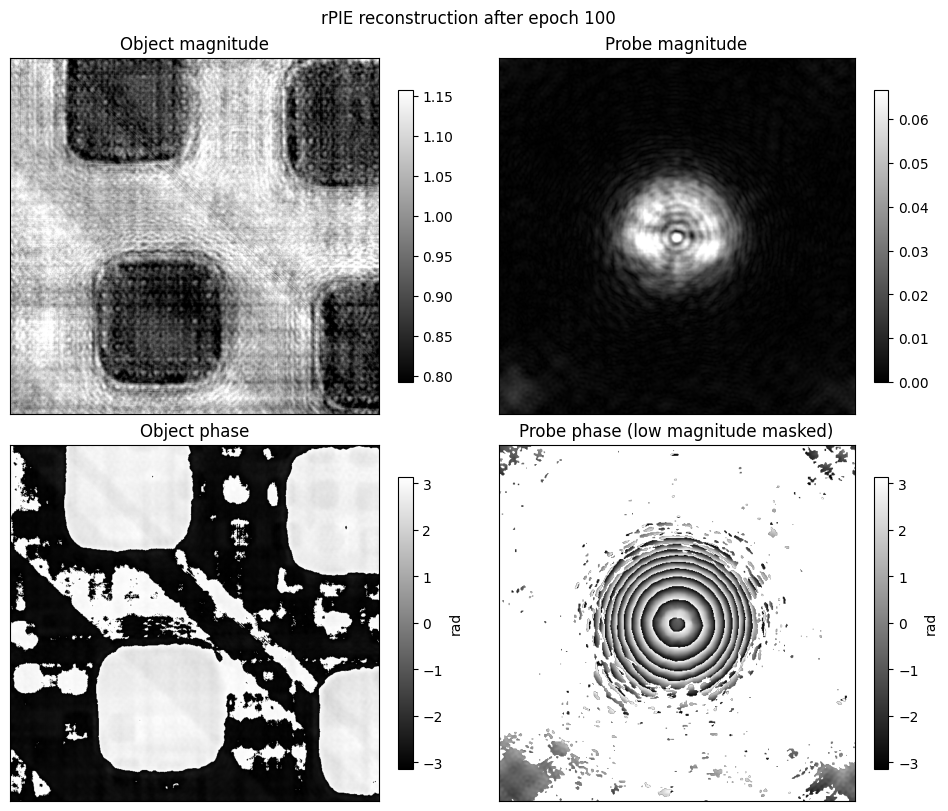


Saved epoch-100 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/rpie/epoch_000100.npz
rPIE: epoch 200/200, online=3.933e-01

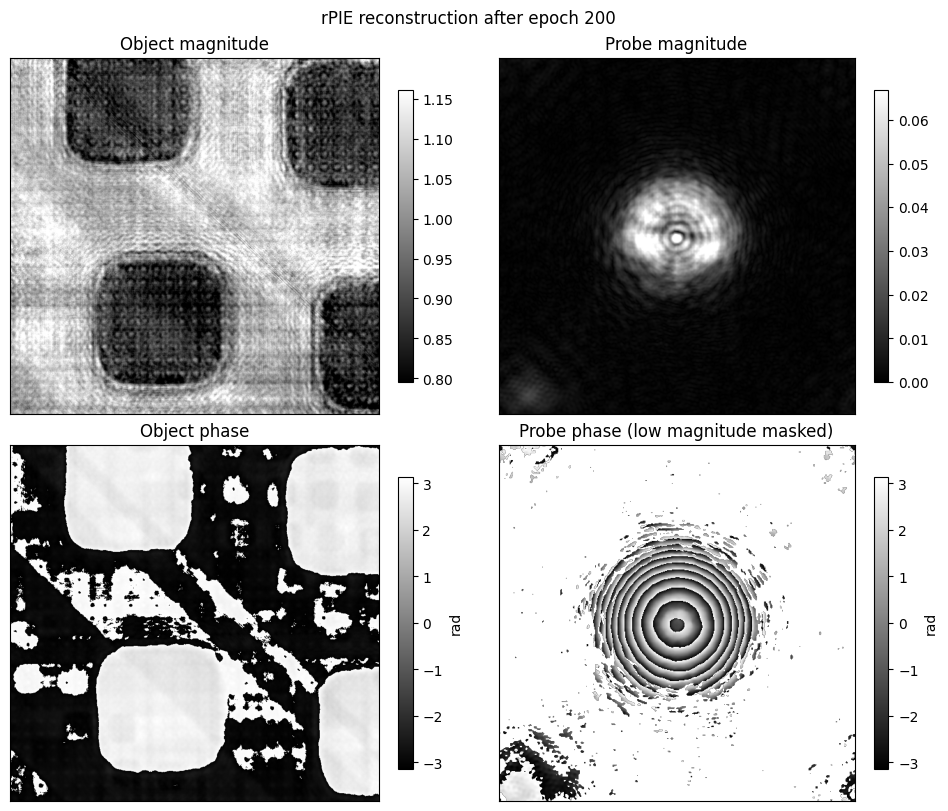


Saved epoch-200 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/rpie/epoch_000200.npz

rPIE finished in 0.91 min
Verified checkpoint: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/rpie
Completed immutable trial 20260905T065958_819999Z. Use show_saved_trials('rPIE') to compare saved trials.


In [5]:
# Tune this method in Shared settings, or insert a config reassignment
# immediately before the next line. The exact object passed below is
# archived. A repeated/configuration-changed execution receives a fresh
# run ID automatically; earlier numeric arrays are never overwritten.
trial_run_id = begin_method_run("rPIE", rpie_cfg)
print("Running rPIE with {}".format(rpie_cfg), flush=True)
torch.cuda.synchronize()
started = perf_counter()
rpie_result = run_real_rpie(
    dataset,
    rpie_cfg,
    device,
    **reconstruction_kwargs("rPIE", trial_run_id),
)
torch.cuda.synchronize()
rpie_result_runtime_seconds = perf_counter() - started
rpie_result_checkpoint = checkpoint_result(
    'rPIE',
    rpie_result,
    rpie_result_runtime_seconds,
    run_id=trial_run_id,
)


## LSQML


LSQML trial run ID: 20260905T065958_819999Z
Running LSQML with {'noise_model': 'gaussian', 'object_step_size': 1.0, 'probe_step_size': 1.0, 'object_optimal_step_size_scaler': 0.5, 'probe_optimal_step_size_scaler': 0.5, 'gaussian_noise_std': 0.5}
LSQML: epoch 100/200, online=3.792e-01

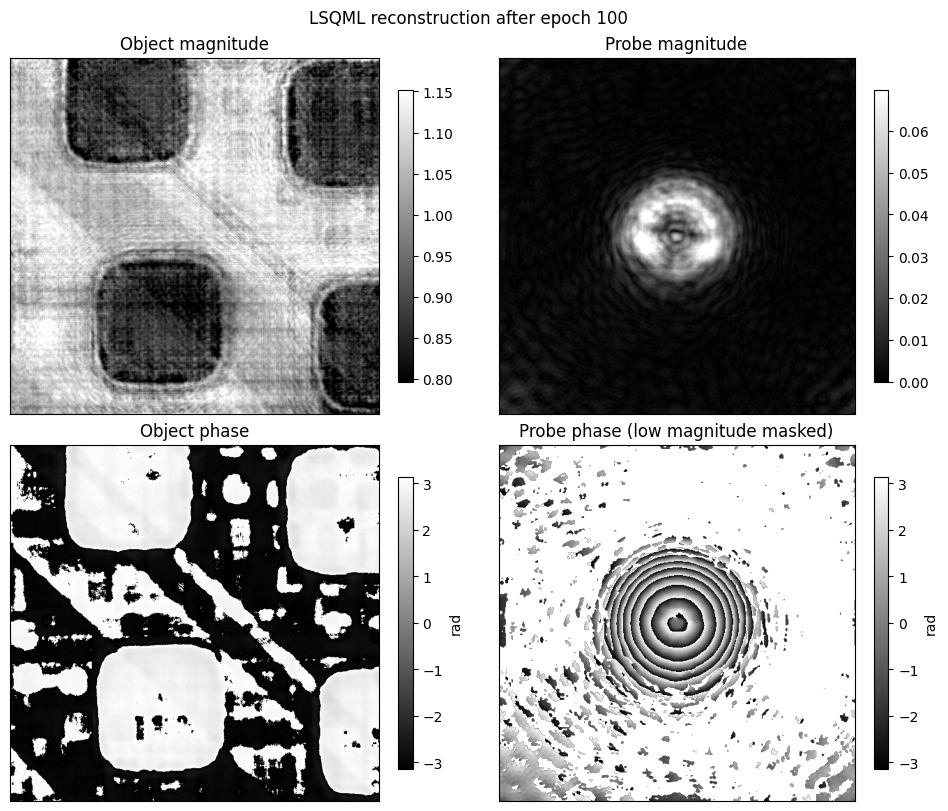


Saved epoch-100 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/lsqml/epoch_000100.npz
LSQML: epoch 200/200, online=3.738e-01

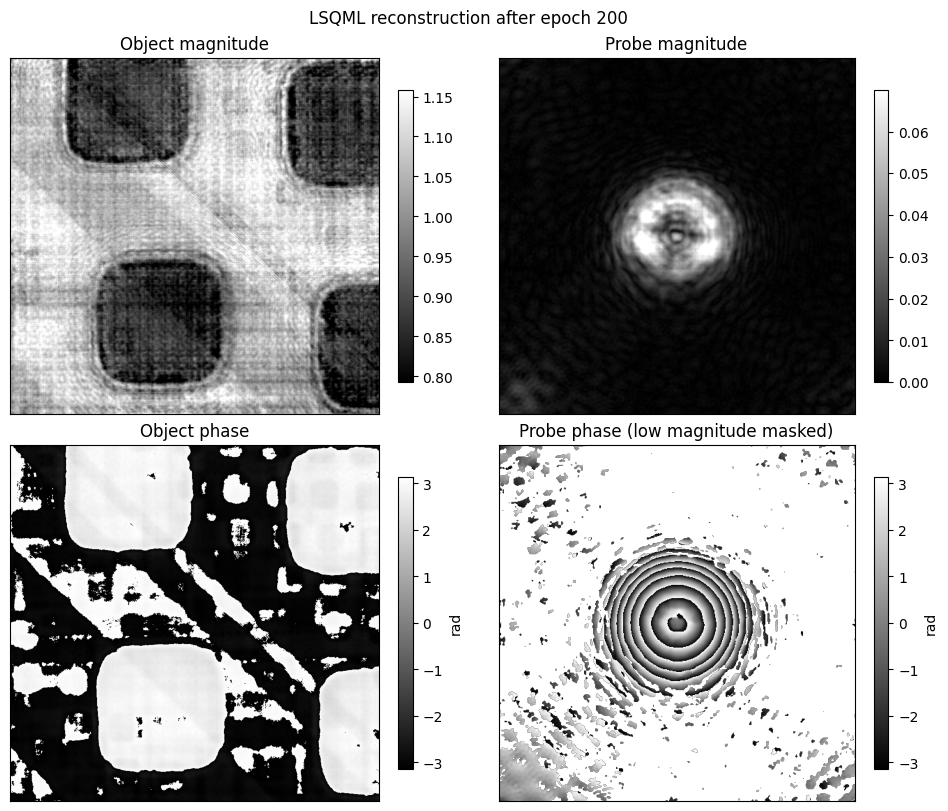


Saved epoch-200 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/lsqml/epoch_000200.npz

LSQML finished in 1.40 min
Verified checkpoint: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/lsqml
Completed immutable trial 20260905T065958_819999Z. Use show_saved_trials('LSQML') to compare saved trials.


In [6]:
# Tune this method in Shared settings, or insert a config reassignment
# immediately before the next line. The exact object passed below is
# archived. A repeated/configuration-changed execution receives a fresh
# run ID automatically; earlier numeric arrays are never overwritten.
trial_run_id = begin_method_run(
    "LSQML",
    lsqml_cfg,
    hyperparameters=lsqml_hyperparameters,
)
print("Running LSQML with {}".format(LSQML_PARAMETERS), flush=True)
torch.cuda.synchronize()
started = perf_counter()
lsqml_result = run_real_lsqml(
    dataset,
    lsqml_cfg,
    device,
    hyperparameters=lsqml_hyperparameters,
    **reconstruction_kwargs("LSQML", trial_run_id),
)
torch.cuda.synchronize()
lsqml_result_runtime_seconds = perf_counter() - started
lsqml_result_checkpoint = checkpoint_result(
    'LSQML',
    lsqml_result,
    lsqml_result_runtime_seconds,
    run_id=trial_run_id,
)


## GM-rPIE


GM-rPIE trial run ID: 20260905T065958_819999Z
Running GM-rPIE with RealDataConfig(data_path=PosixPath('<original-project>/assets/ptycho_real_data/Velo_18c3_comm_chip65nm_scan054_data_roi0_Ndp512_us2.hdf5'), fzp_defocus_m=-0.001, pattern_stride=1, max_patterns=None, fft_shift_data=True, num_epochs=200, batch_size=29, object_extra_pixels=20, seed=42, object_alpha=1.0, object_step_size=1.0, probe_alpha=0.1, probe_step_size=1.0, probe_update_start_epoch=0, probe_update_stride=1, save_data_on_device=True, remove_object_probe_ambiguity=True, random_pattern_fraction=None)
GM-rPIE: epoch 100/200, online=3.696e-01

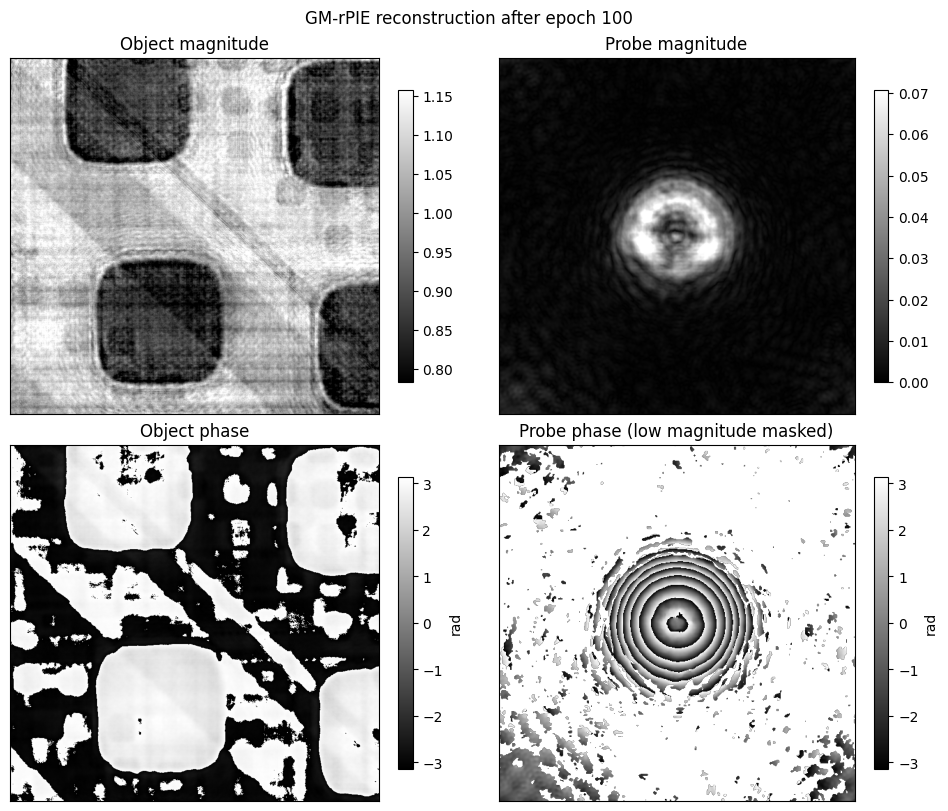


Saved epoch-100 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/gm_rpie/epoch_000100.npz
GM-rPIE: epoch 200/200, online=3.593e-01

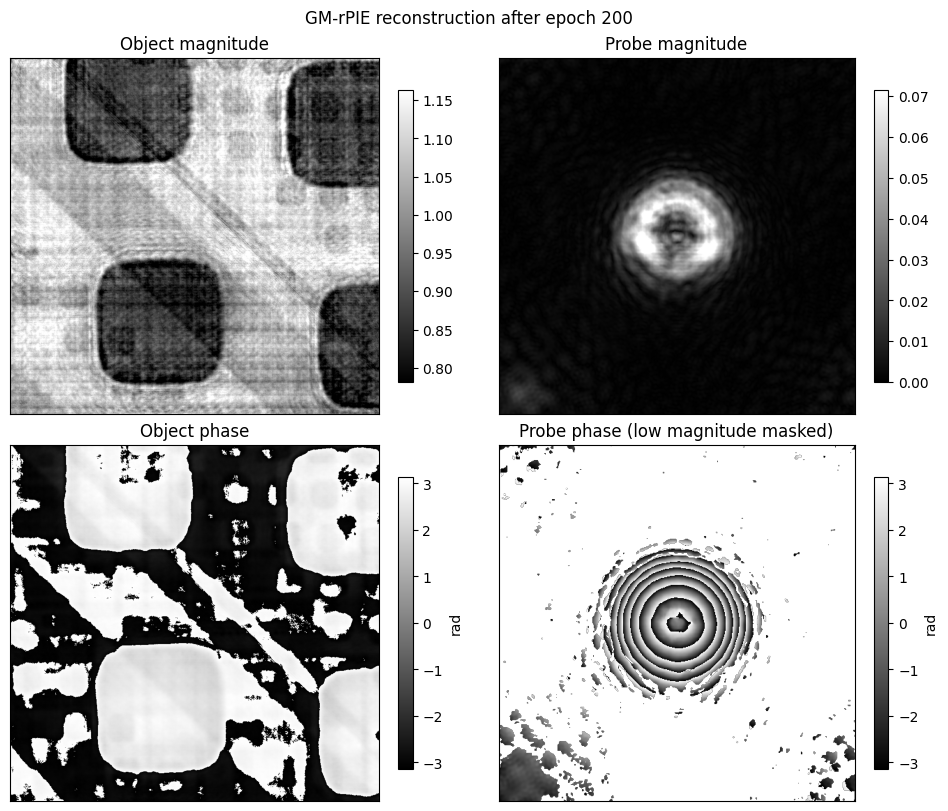


Saved epoch-200 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/gm_rpie/epoch_000200.npz

GM-rPIE finished in 1.50 min
Verified checkpoint: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/gm_rpie
Completed immutable trial 20260905T065958_819999Z. Use show_saved_trials('GM-rPIE') to compare saved trials.


In [7]:
# Tune this method in Shared settings, or insert a config reassignment
# immediately before the next line. The exact object passed below is
# archived. A repeated/configuration-changed execution receives a fresh
# run ID automatically; earlier numeric arrays are never overwritten.
trial_run_id = begin_method_run("GM-rPIE", gm_rpie_cfg)
print("Running GM-rPIE with {}".format(gm_rpie_cfg), flush=True)
torch.cuda.synchronize()
started = perf_counter()
gm_rpie_result = run_real_gm_rpie(
    dataset,
    gm_rpie_cfg,
    device,
    **reconstruction_kwargs("GM-rPIE", trial_run_id),
)
torch.cuda.synchronize()
gm_rpie_result_runtime_seconds = perf_counter() - started
gm_rpie_result_checkpoint = checkpoint_result(
    'GM-rPIE',
    gm_rpie_result,
    gm_rpie_result_runtime_seconds,
    run_id=trial_run_id,
)


## GM-MAGPIE


GM-MAGPIE trial run ID: 20260905T065958_819999Z
Running GM-MAGPIE with RealDataConfig(data_path=PosixPath('<original-project>/assets/ptycho_real_data/Velo_18c3_comm_chip65nm_scan054_data_roi0_Ndp512_us2.hdf5'), fzp_defocus_m=-0.001, pattern_stride=1, max_patterns=None, fft_shift_data=True, num_epochs=200, batch_size=29, object_extra_pixels=20, seed=42, object_alpha=3.0, object_step_size=1.0, probe_alpha=0.1, probe_step_size=1.0, probe_update_start_epoch=0, probe_update_stride=1, save_data_on_device=True, remove_object_probe_ambiguity=True, random_pattern_fraction=None)
GM-MAGPIE: epoch 100/200, online=3.763e-01

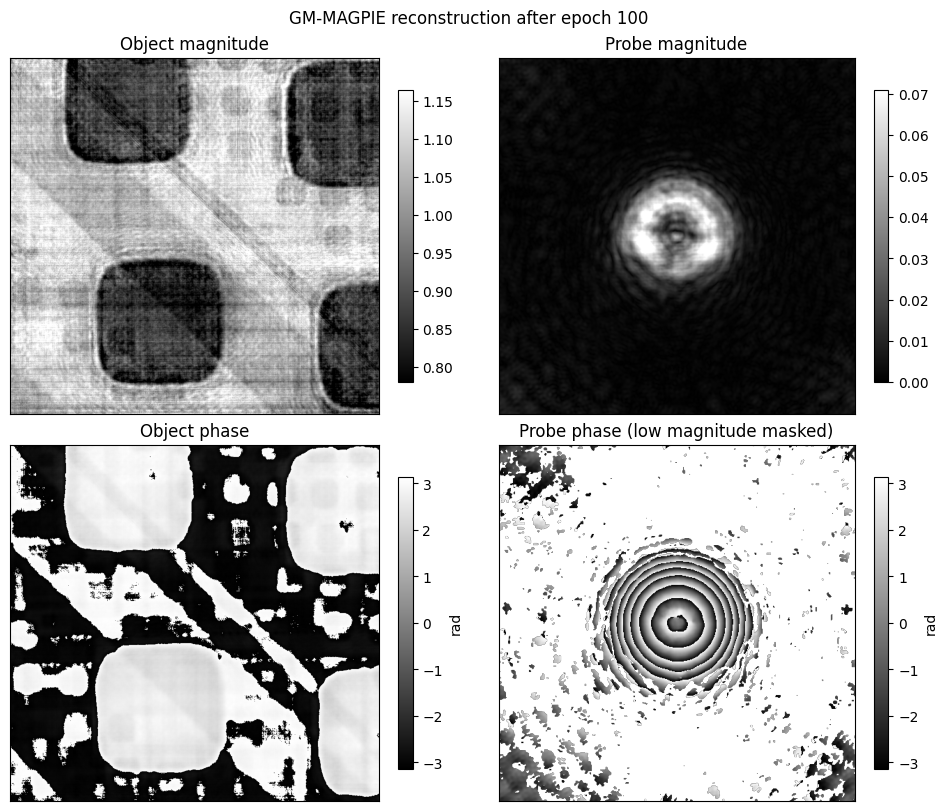


Saved epoch-100 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/gm_magpie/epoch_000100.npz
GM-MAGPIE: epoch 200/200, online=3.742e-01

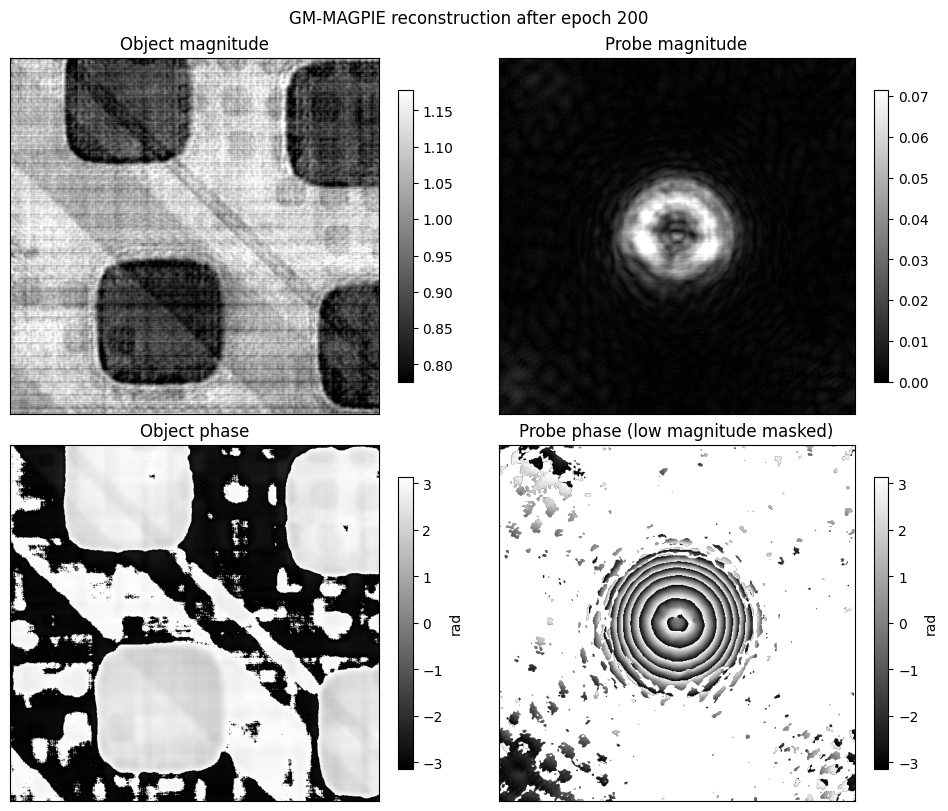


Saved epoch-200 reconstruction: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/_epoch_snapshots/gm_magpie/epoch_000200.npz

GM-MAGPIE finished in 1.86 min
Verified checkpoint: <original-project>/results/notebook_exports/chip_full/_checkpoints/20260905T065958_819999Z/gm_magpie
Completed immutable trial 20260905T065958_819999Z. Use show_saved_trials('GM-MAGPIE') to compare saved trials.


In [8]:
# Tune this method in Shared settings, or insert a config reassignment
# immediately before the next line. The exact object passed below is
# archived. A repeated/configuration-changed execution receives a fresh
# run ID automatically; earlier numeric arrays are never overwritten.
trial_run_id = begin_method_run("GM-MAGPIE", gm_magpie_cfg)
print("Running GM-MAGPIE with {}".format(gm_magpie_cfg), flush=True)
torch.cuda.synchronize()
started = perf_counter()
gm_magpie_result = run_real_gm_magpie(
    dataset,
    gm_magpie_cfg,
    device,
    **reconstruction_kwargs("GM-MAGPIE", trial_run_id),
)
torch.cuda.synchronize()
gm_magpie_result_runtime_seconds = perf_counter() - started
gm_magpie_result_checkpoint = checkpoint_result(
    'GM-MAGPIE',
    gm_magpie_result,
    gm_magpie_result_runtime_seconds,
    run_id=trial_run_id,
)


## Validate and align reconstructions


In [9]:
if tuple(results) != METHOD_ORDER:
    missing = [name for name in METHOD_ORDER if name not in results]
    raise RuntimeError("Run all method cells first; missing: " + ", ".join(missing))

if archive_session is None or alignment_fit_mask is None:
    raise RuntimeError("The checkpoint session was not initialized.")
for mapping_name, mapping in (
    ("aligned_objects", aligned_objects),
    ("aligned_probes", aligned_probes),
    ("alignments", alignments),
):
    if tuple(mapping) != METHOD_ORDER:
        raise RuntimeError(f"Incomplete {mapping_name} checkpoints.")

print(
    f"{'method':<12} {'runtime (min)':>14} "
    f"{'online final':>16}"
)
print("-" * 44)
for method_name in METHOD_ORDER:
    result = results[method_name]
    print(
        f"{method_name:<12} {runtimes_seconds[method_name] / 60:>14.2f} "
        f"{result.residual_history[-1]:>16.6e}"
    )


method        runtime (min)     online final
--------------------------------------------
rPIE                   0.91     3.933387e-01
LSQML                  1.40     3.738158e-01
GM-rPIE                1.50     3.593370e-01
GM-MAGPIE              1.86     3.741508e-01


## Save numeric results before plotting

Each method cell above has already written its own verified,
immutable checkpoint before the next method starts. This final cell
requires all four checkpoints and assembles the comparison archive.
It contains raw and aligned final complex objects and probes, all
periodic object/probe snapshots, complete online residuals, exact
selected pattern indices and scan metadata, method configurations,
runtimes, source/input hashes, validation records, and SHA-256
checksums. The measured diffraction stack is referenced and hashed,
not duplicated into every run archive.


In [10]:
if tuple(results) != METHOD_ORDER:
    raise RuntimeError("All four methods must be completed before finalizing.")
saved_run_dir = save_real_notebook_results(archive_session)
print(f"Saved and verified complete run: {saved_run_dir}")


Saved and verified complete run: <original-project>/results/notebook_exports/chip_full/20260905T065958_819999Z


Load an archived reconstruction without pickle, for example:

```python
with np.load(
    saved_run_dir / "reconstructions" / "gm_magpie.npz",
    allow_pickle=False,
) as saved:
    object_raw = saved["object"]
    probe_raw = saved["probe"]
    object_aligned = saved["aligned_object"]
    probe_aligned = saved["aligned_probe"]
    residual = saved["residual_history"]
```

Periodic raw snapshots are under `snapshots/<method>/epoch_*.npz`.
The authoritative online curve and scalar table are
`curves/residual_history.csv` and `tables/summary.csv`. A complete
archive ends with `_SUCCESS`.


## Residual curves


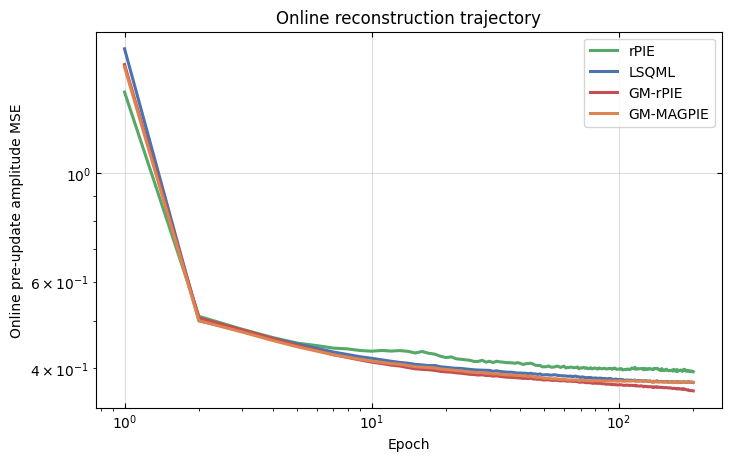

In [11]:
methods = completed_methods()
fig, axis = plt.subplots(figsize=(7.2, 4.5), constrained_layout=True)
for method_name in methods:
    result = results[method_name]
    online_epochs = np.arange(1, len(result.residual_history) + 1)
    online_valid = np.isfinite(result.residual_history) & (
        result.residual_history > 0
    )
    axis.loglog(
        online_epochs[online_valid],
        result.residual_history[online_valid],
        linewidth=2.2,
        color=METHOD_COLORS[method_name],
        label=method_name,
    )
axis.set(
    title="Online reconstruction trajectory",
    xlabel="Epoch",
    ylabel="Online pre-update amplitude MSE",
)
axis.grid(True, which="major", alpha=0.4)
axis.grid(False, which="minor")
axis.tick_params(direction="in", top=True, right=True)
axis.legend()
plt.show()


## Object comparison


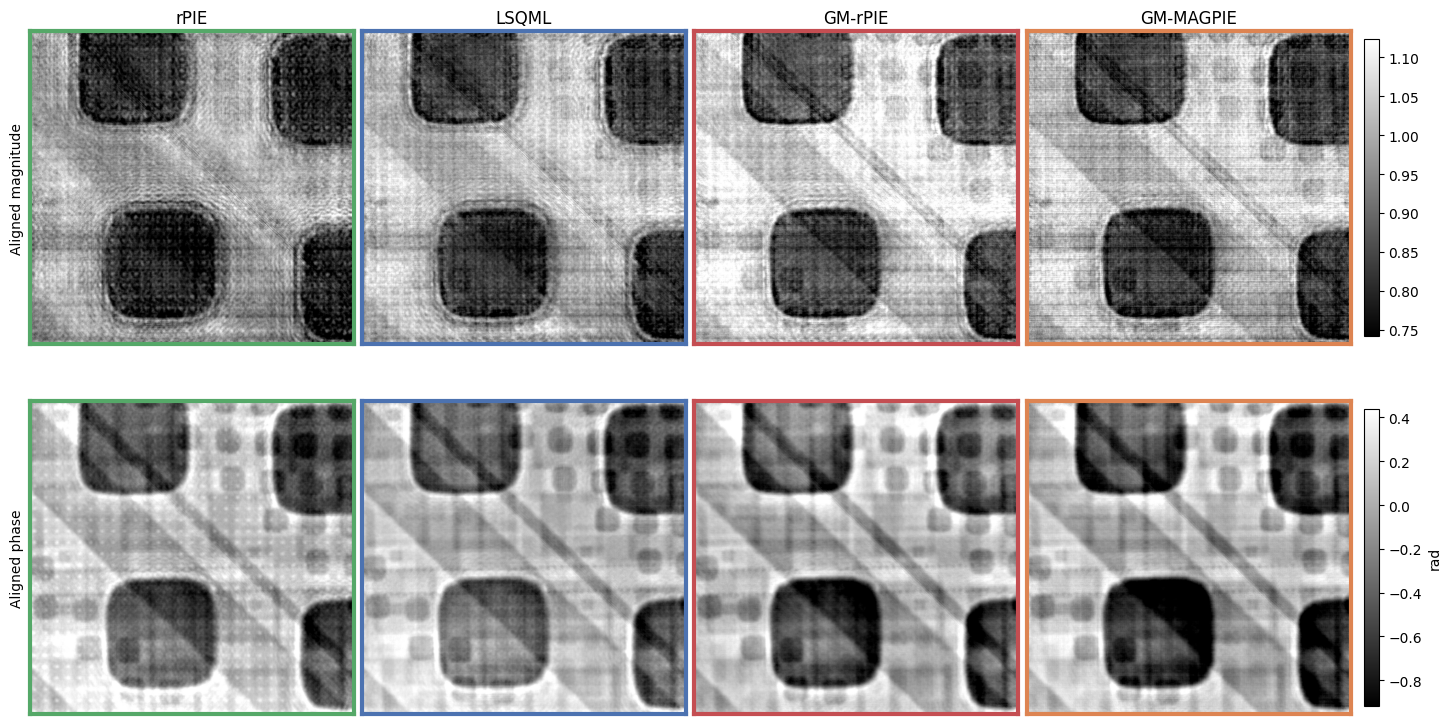

In [12]:
methods = [name for name in METHOD_ORDER if name in aligned_objects]
boundary_width = tuple(
    length // 2 for length in dataset.probe_init.shape[-2:]
)
object_shape = aligned_objects[methods[0]].shape
object_view = tuple(
    slice(cutoff, length - cutoff)
    for cutoff, length in zip(boundary_width, object_shape)
)
object_views = {
    name: aligned_objects[name][object_view]
    for name in methods
}
magnitude_limits = robust_limits(
    np.concatenate(
        [np.abs(value).ravel() for value in object_views.values()]
    ),
    (2, 98),
    nonnegative=True,
)
phase_limits = robust_limits(
    np.concatenate(
        [np.angle(value).ravel() for value in object_views.values()]
    ),
    (2, 98),
)

fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(3.6 * len(methods), 7.4),
    constrained_layout=True,
    squeeze=False,
)
for column, (method_name, value) in enumerate(object_views.items()):
    magnitude_image = axes[0, column].imshow(
        np.abs(value),
        cmap="gray",
        vmin=magnitude_limits[0],
        vmax=magnitude_limits[1],
    )
    phase_image = axes[1, column].imshow(
        np.angle(value),
        cmap="gray",
        vmin=phase_limits[0],
        vmax=phase_limits[1],
    )
    axes[0, column].set_title(method_name)
    for axis in axes[:, column]:
        axis.set(xticks=[], yticks=[])
        for spine in axis.spines.values():
            spine.set_color(METHOD_COLORS[method_name])
            spine.set_linewidth(3.0)

axes[0, 0].set_ylabel("Aligned magnitude")
axes[1, 0].set_ylabel("Aligned phase")
fig.colorbar(magnitude_image, ax=axes[0, :], shrink=0.82, pad=0.01)
fig.colorbar(
    phase_image,
    ax=axes[1, :],
    shrink=0.82,
    pad=0.01,
    label="rad",
)
plt.show()


## Probe comparison


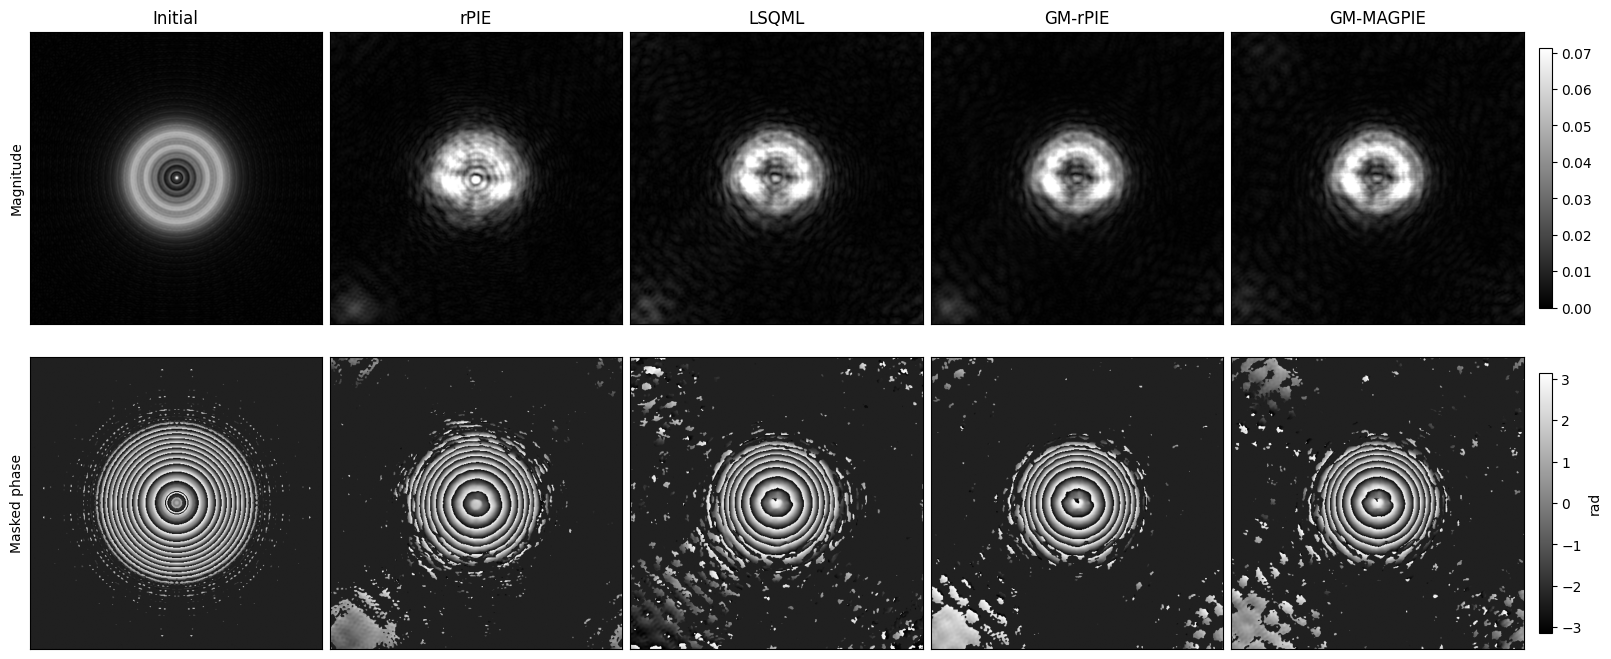

In [13]:
methods = [name for name in METHOD_ORDER if name in aligned_probes]
probes = {
    "Initial": np.squeeze(dataset.probe_init),
    **{name: aligned_probes[name] for name in methods},
}
probe_vmax = robust_limits(
    np.concatenate([np.abs(value).ravel() for value in probes.values()]),
    (0, 99.5),
    nonnegative=True,
)[1]
phase_threshold = 0.05 * probe_vmax
phase_cmap = plt.colormaps["gray"].copy()
phase_cmap.set_bad("#202020")

fig, axes = plt.subplots(
    2,
    len(probes),
    figsize=(3.2 * len(probes), 6.6),
    constrained_layout=True,
    squeeze=False,
)
for column, (name, value) in enumerate(probes.items()):
    magnitude = np.abs(value)
    phase = np.ma.masked_where(
        (magnitude < phase_threshold) | ~np.isfinite(magnitude),
        np.angle(value),
    )
    magnitude_image = axes[0, column].imshow(
        magnitude,
        cmap="gray",
        vmin=0,
        vmax=probe_vmax,
    )
    phase_image = axes[1, column].imshow(
        phase,
        cmap=phase_cmap,
        vmin=-np.pi,
        vmax=np.pi,
    )
    axes[0, column].set_title(name)
    for axis in axes[:, column]:
        axis.set(xticks=[], yticks=[])

axes[0, 0].set_ylabel("Magnitude")
axes[1, 0].set_ylabel("Masked phase")
fig.colorbar(magnitude_image, ax=axes[0, :], shrink=0.82, pad=0.01)
fig.colorbar(
    phase_image,
    ax=axes[1, :],
    shrink=0.82,
    pad=0.01,
    label="rad",
)
plt.show()
